In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
import json
import os.path
import torch
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pickle
from shapely.geometry import Point
import scienceplots
plt.style.use(['science', "no-latex"])
import random
import time

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [3]:
# import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [4]:
kitgreen="#009682"
green="#98BF64"
kitblue="#4664AA"
grey5="#f2f2f2ff"
grey30="#b3b3b3ff"

In [5]:
# seed = random.randint(0, 10000)
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
train_interested_locations = {
    "TLH2": {},
    "TLH3": {},
    "TLJ1":{},
    "TLF1":{},
    "TLF2":{},
    "TLC1":{},
    "TLC2":{},
    "TLD6":{},
    "TLG1":{},
    "TLG2":{},
    "TLE4":{},
}

In [7]:
test_interested_locations = {
    "London": {},
    "TLH1": {},
    "TLE3":{},
    "TLD3":{},
    "TLD4":{},
}

In [8]:
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Batch

In [9]:
train_graph_data_list = []

# 假设您有多个图数据，每个图数据格式如下：
for i, location in enumerate(train_interested_locations):  # your_multiple_graphs是您的多图数据
    with open(f"./results/intermediate/GNN/{location}_prepared_graph_data.pt", "rb") as f:
        graph_data = torch.load(f, weights_only=False)

    train_graph_data_list.append(graph_data)

train_dataloader = DataLoader(train_graph_data_list, batch_size=1, shuffle=False)

In [10]:
test_graph_data_list = []

# 假设您有多个图数据，每个图数据格式如下：
for i, location in enumerate(test_interested_locations):  # your_multiple_graphs是您的多图数据
    with open(f"./results/intermediate/GNN/{location}_prepared_graph_data.pt", "rb") as f:
        graph_data = torch.load(f, weights_only=False)

    test_graph_data_list.append(graph_data)

test_dataloader = DataLoader(test_graph_data_list, batch_size=1, shuffle=False)

In [11]:
from SpatialAllocation.GNN.core.EdgeWeightSolver import EdgeWeightSolver
from SpatialAllocation.GNN.core.ModelConfig import ModelConfig

In [12]:
epochs = 1000
config = ModelConfig(
        hidden_dim=256,
        embedding_dim=128,
        num_layers=3,
        conv_type="hgt",  # 可选: 'gcn', 'sage', 'gat', 'gin', 'hgt'
        allocation_temperature_start=0.01,
        clip_grad_norm=None,
        learning_rate=1e-3,
        weight_decay=1e-4,
        epochs=epochs,
        device='cuda',
        debug=False,
        use_scheduler = True,
        cosine_epochs = None,  # 周期长度，如果为None则使用总epoch数
        cosine_eta_min = 5e-5,  # 最小学习率
        save_path=f"results/intermediate/gnn_model_SA_{time.time()}_London.pth",
        learnable=False,
    )

solver = EdgeWeightSolver(config)

没有提供测试数据加载器，将仅进行训练。
开始原生异构图模型训练与测试...
Epoch 1/1000 completed in 0.39s | Avg Train Loss: 19.678808 | Avg Test Loss: inf | LR: 0.001000 | Avg Grad Norm: 114.770500
  -> Epoch 1, ** 新的最佳模型已保存 (Test Loss: 19.678808) **
Epoch 2/1000 completed in 0.13s | Avg Train Loss: 22.603907 | Avg Test Loss: inf | LR: 0.001000 | Avg Grad Norm: 243.109665
Epoch 3/1000 completed in 0.13s | Avg Train Loss: 22.584686 | Avg Test Loss: inf | LR: 0.001000 | Avg Grad Norm: 106.885269
Epoch 4/1000 completed in 0.13s | Avg Train Loss: 19.336758 | Avg Test Loss: inf | LR: 0.001000 | Avg Grad Norm: 117.016846
  -> Epoch 4, ** 新的最佳模型已保存 (Test Loss: 19.336758) **
Epoch 5/1000 completed in 0.13s | Avg Train Loss: 18.259104 | Avg Test Loss: inf | LR: 0.001000 | Avg Grad Norm: 85.241447
  -> Epoch 5, ** 新的最佳模型已保存 (Test Loss: 18.259104) **
Epoch 6/1000 completed in 0.11s | Avg Train Loss: 15.361739 | Avg Test Loss: inf | LR: 0.001000 | Avg Grad Norm: 75.185646
  -> Epoch 6, ** 新的最佳模型已保存 (Test Loss: 15.361739) **
Epoch 7/

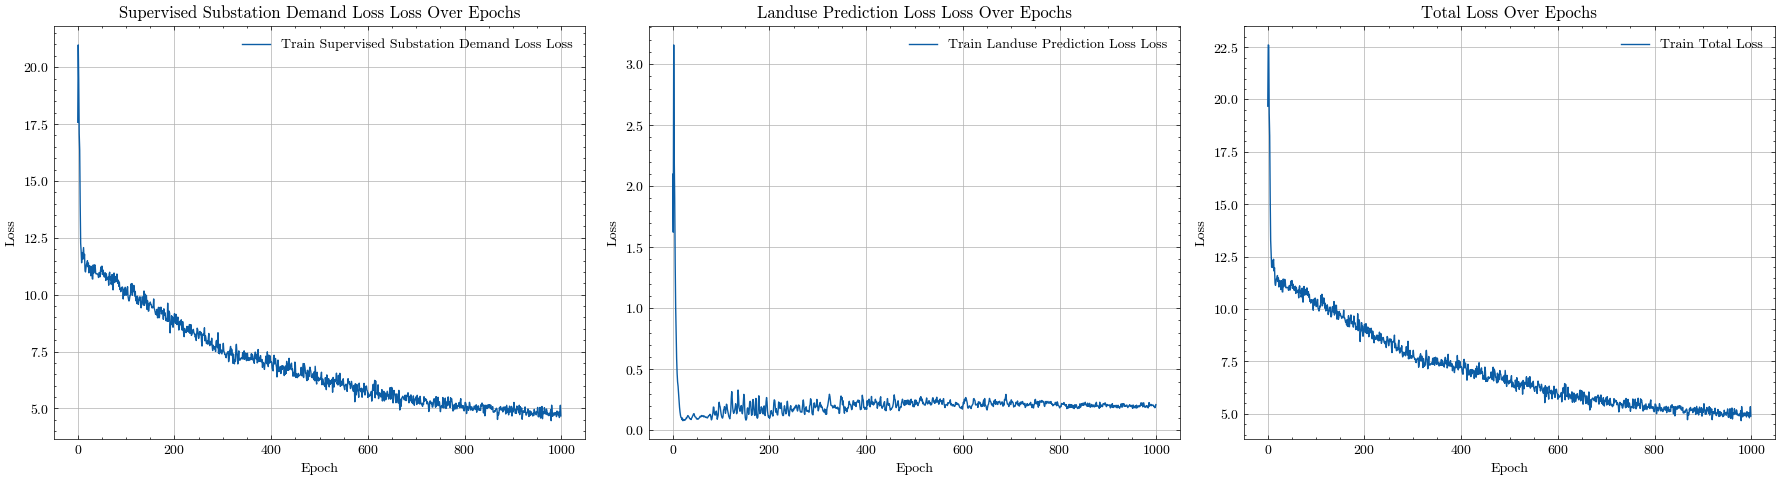

原生异构图训练和测试完成!


In [13]:
weights = {
    # 'supervised_substation_demand_loss': 1.0,
    # 'entropy_regularization': 0.05,
    # 'feature_similarity_loss': 1,
    # 'feature_consistency_loss': 1,
    'landuse_prediction_loss': 1.0,
}
# solver.train_multi_graph(train_dataloader, test_dataloader, weights)
solver.train_multi_graph(train_dataloader, objective_weights=weights)

In [14]:
interested_locations = list(train_interested_locations.keys()) + list(test_interested_locations.keys())

In [15]:
graph_data_list = []

# 假设您有多个图数据，每个图数据格式如下：
for i, location in enumerate(interested_locations):  # your_multiple_graphs是您的多图数据
    with open(f"./results/intermediate/GNN/{location}_prepared_graph_data.pt", "rb") as f:
        graph_data = torch.load(f, weights_only=False)

    graph_data_list.append(graph_data)

dataloader = DataLoader(graph_data_list, batch_size=1, shuffle=True)

In [16]:
with open("./results/intermediate/static_matrix.pickle", "rb") as f:
    matrix = pickle.load(f)

In [17]:
cols = interested_locations
corr_matrix = matrix["corr_matrix"]
rmse_matrix = matrix["rmse_matrix"]
mae_matrix = matrix["mae_matrix"]

In [18]:
ITL3_region = gpd.read_file(r"./results/intermediate/ITL3_region.gpkg")
substations = gpd.read_file(r"./results/intermediate/substations.gpkg")

In [19]:
for i, location in enumerate(interested_locations):
    print(location)
    interested_region = ITL3_region[ITL3_region['ITL2'] == location].reset_index()
    interested_substations = substations[substations['ITL2'] == location].reset_index()

    with open(f"./results/intermediate/GridPoint/{location}_grid_points.pickle", "rb") as f:
        grid_gdf, step_size_m = pickle.load(f)
    grid_gdf = grid_gdf.reset_index()

    voronoi_gdf = gpd.read_file(f"./results/intermediate/voronoi/voronoi_{location}_without_subcolumn.gpkg")

    edge_weights = solver.predict_edge_weights(graph_data_list[i])
    edge_weights = edge_weights.set_index("agent_node_idx").sort_index()["predicted_weight"].values
    grid_gdf["GNN"] = edge_weights * grid_gdf["Demand (MVA)"]

    def calculate_demand(polygon):
        # 找出位于此多边形内的所有点
        points_within = grid_gdf[grid_gdf.geometry.within(polygon.geometry)]

        # 如果有点落在多边形内，计算它们的demand总和；否则返回0
        if not points_within.empty:
            return points_within['GNN'].sum()
        else:
            return 0

    voronoi_gdf['demand'] = voronoi_gdf.apply(calculate_demand, axis=1)

    corr_matrix.loc["GNN", location] = interested_substations["Demand (MVA)"].corr(voronoi_gdf['demand'])
    rmse_matrix.loc["GNN", location] = np.sqrt(((interested_substations["Demand (MVA)"] - voronoi_gdf['demand']) ** 2).mean())
    mae_matrix.loc["GNN", location] = np.abs(interested_substations["Demand (MVA)"] - voronoi_gdf['demand']).mean()

London
成功从 'results/intermediate/gnn_model_SA_1756187499.4596026_London.pth' 加载模型。

=== 边权重预测结果统计 ===
总体 MAE (对比均匀分布): 0.000475
平均权重和误差 (应接近0): 0.000002
权重范围: [0.0000, 0.2814]

已生成包含原始索引和权重的 DataFrame。
TLD3
成功从 'results/intermediate/gnn_model_SA_1756187499.4596026_London.pth' 加载模型。

=== 边权重预测结果统计 ===
总体 MAE (对比均匀分布): 0.000109
平均权重和误差 (应接近0): 0.000025
权重范围: [0.0000, 0.0110]

已生成包含原始索引和权重的 DataFrame。


In [20]:
for i, location in enumerate(interested_locations):
    print(location)
    interested_region = ITL3_region[ITL3_region['ITL2'] == location].reset_index()
    interested_substations = substations[substations['ITL2'] == location].reset_index()

    with open(f"./results/intermediate/GridPoint/{location}_grid_points.pickle", "rb") as f:
        grid_gdf, step_size_m = pickle.load(f)
    grid_gdf = grid_gdf.reset_index()

    with open(f"./results/intermediate/Pyomo/hdbscan_voronoi_result_british_{location}.pkl", "rb") as f:
        voronoi_gdf = pickle.load(f)

    edge_weights = solver.predict_edge_weights(graph_data_list[i])
    edge_weights = edge_weights.set_index("agent_node_idx").sort_index()["predicted_weight"].values
    grid_gdf["GNN"] = edge_weights * grid_gdf["Demand (MVA)"]

    def calculate_demand(polygon):
        # 找出位于此多边形内的所有点
        points_within = grid_gdf[grid_gdf.geometry.within(polygon.geometry)]

        # 如果有点落在多边形内，计算它们的demand总和；否则返回0
        if not points_within.empty:
            return points_within['GNN'].sum()
        else:
            return 0

    voronoi_gdf['demand'] = voronoi_gdf.apply(calculate_demand, axis=1)
    voronoi_gdf = voronoi_gdf.to_crs("EPSG:3857")
    interested_substations = interested_substations.to_crs("EPSG:3857")
    joined_gdf = gpd.sjoin_nearest(interested_substations, voronoi_gdf, how="left")
    interested_substations['cluster_label'] = joined_gdf['cluster_label']
    counts = interested_substations["cluster_label"].value_counts()
    interested_substations["hdbscan"] = interested_substations["cluster_label"].apply(lambda x: voronoi_gdf.loc[x, "demand"]/counts[x])


    corr_matrix.loc["GNN_hdbscan", location] = interested_substations["Demand (MVA)"].corr(interested_substations["hdbscan"])
    rmse_matrix.loc["GNN_hdbscan", location] = np.sqrt(((interested_substations["Demand (MVA)"] - interested_substations["hdbscan"]) ** 2).mean())
    mae_matrix.loc["GNN_hdbscan", location] = np.abs(interested_substations["Demand (MVA)"] - interested_substations["hdbscan"]).mean()

London
成功从 'results/intermediate/gnn_model_SA_1756187499.4596026_London.pth' 加载模型。

=== 边权重预测结果统计 ===
总体 MAE (对比均匀分布): 0.000475
平均权重和误差 (应接近0): 0.000002
权重范围: [0.0000, 0.2814]

已生成包含原始索引和权重的 DataFrame。
TLD3
成功从 'results/intermediate/gnn_model_SA_1756187499.4596026_London.pth' 加载模型。

=== 边权重预测结果统计 ===
总体 MAE (对比均匀分布): 0.000109
平均权重和误差 (应接近0): 0.000025
权重范围: [0.0000, 0.0110]

已生成包含原始索引和权重的 DataFrame。


In [21]:
print(len(interested_locations))

2


In [22]:
train_count = 0
count = 0
results = {}
results["improvement"] = []
results["degradation"] = []
improvement_percentages = []
for i, location in enumerate(interested_locations):
    if rmse_matrix.loc["GNN", location] < rmse_matrix.loc["voronoi", location]:
        count += 1
        results["improvement"].append(location)

        percentage = (1 - (rmse_matrix.loc["GNN", location]/ rmse_matrix.loc["voronoi", location])) * 100
        improvement_percentages.append(percentage)

        if location in train_interested_locations.keys():
            train_count += 1
    else:
        results["degradation"].append(location)
print(f"Total {count} of {len(interested_locations)} locations have performance improvement in RMSE, {train_count}/{len(train_interested_locations.keys())} of them are in the train set.")
print(f"{results['improvement']} are improved.")
print(f"Maximum improvement: {max(improvement_percentages):.2f}%")
print(f"Minimum improvement: {min(improvement_percentages):.2f}%")
print(f"Average improvement: {np.mean(improvement_percentages):.2f}%")
print(f"{results['degradation']} are degraded.")

Total 1 of 2 locations have performance improvement in RMSE, 1/1 of them are in the train set.
['London'] are improved.
Maximum improvement: 29.80%
Minimum improvement: 29.80%
Average improvement: 29.80%
['TLD3'] are degraded.


In [23]:
# train_count = 0
# count = 0
# results = {}
# results["improvement"] = []
# results["degradation"] = []
# improvement_percentages = []
# for i, location in enumerate(interested_locations):
#     if mae_matrix.loc["GNN", location] < mae_matrix.loc["voronoi", location]:
#         count += 1
#         results["improvement"].append(location)
#
#         percentage = (1 - (mae_matrix.loc["GNN", location]/ mae_matrix.loc["voronoi", location])) * 100
#         improvement_percentages.append(percentage)
#
#         if location in train_interested_locations.keys():
#             train_count += 1
#     else:
#         results["degradation"].append(location)
# print(f"Total {count} of {len(interested_locations)} locations have performance improvement in MAE, {train_count}/{len(train_interested_locations.keys())} of them are in the train set.")
# print(f"Maximum improvement: {max(improvement_percentages):.2f}%")
# print(f"Minimum improvement: {min(improvement_percentages):.2f}%")
# print(f"Average improvement: {np.mean(improvement_percentages):.2f}%")
# print(f"{results['improvement']} are improved.")
# print(f"{results['degradation']} are degraded.")

In [24]:
train_count = 0
count = 0
results = {}
results["improvement"] = []
results["degradation"] = []
improvement_percentages = []
for i, location in enumerate(interested_locations):
    if rmse_matrix.loc["GNN_hdbscan", location] < rmse_matrix.loc["civd_gpm", location]:
        count += 1
        results["improvement"].append(location)

        percentage = (1 - (rmse_matrix.loc["GNN_hdbscan", location]/ rmse_matrix.loc["civd_gpm", location])) * 100
        improvement_percentages.append(percentage)

        if location in train_interested_locations.keys():
            train_count += 1
    else:
        results["degradation"].append(location)
print(f"Total {count} of {len(interested_locations)} locations have performance improvement in RMSE by civd, {train_count}/{len(train_interested_locations.keys())} of them are in the train set.")
print(f"{results['improvement']} are improved.")
print(f"Maximum improvement: {max(improvement_percentages):.2f}%")
print(f"Minimum improvement: {min(improvement_percentages):.2f}%")
print(f"Average improvement: {np.mean(improvement_percentages):.2f}%")
print(f"{results['degradation']} are degraded.")

Total 1 of 2 locations have performance improvement in RMSE by civd, 1/1 of them are in the train set.
['London'] are improved.
Maximum improvement: 13.11%
Minimum improvement: 13.11%
Average improvement: 13.11%
['TLD3'] are degraded.


In [25]:
# train_count = 0
# count = 0
# results = {}
# results["improvement"] = []
# results["degradation"] = []
# improvement_percentages = []
# for i, location in enumerate(interested_locations):
#     if mae_matrix.loc["GNN_hdbscan", location] < mae_matrix.loc["civd_gpm", location]:
#         count += 1
#         results["improvement"].append(location)
#
#         percentage = (1 - (mae_matrix.loc["GNN_hdbscan", location]/ mae_matrix.loc["civd_gpm", location])) * 100
#         improvement_percentages.append(percentage)
#
#         if location in train_interested_locations.keys():
#             train_count += 1
#     else:
#         results["degradation"].append(location)
# print(f"Total {count} of {len(interested_locations)} locations have performance improvement in MAE by civd, {train_count}/{len(train_interested_locations.keys())} of them are in the train set.")
# print(f"{results['improvement']} are improved.")
# print(f"Maximum improvement: {max(improvement_percentages):.2f}%")
# print(f"Minimum improvement: {min(improvement_percentages):.2f}%")
# print(f"Average improvement: {np.mean(improvement_percentages):.2f}%")
# print(f"{results['degradation']} are degraded.")

In [26]:
rmse_matrix[list(train_interested_locations.keys())]

,London
simple_voronoi,21.085062
voronoi,16.234218
civd_gpm,16.219879
ITL3_average,14.429478
ITL2_average,18.116889
GNN,11.395876
GNN_hdbscan,14.094255


In [27]:
rmse_matrix[list(test_interested_locations.keys())]

,TLD3
simple_voronoi,10.199783
voronoi,7.067501
civd_gpm,6.578768
ITL3_average,4.382415
ITL2_average,4.485602
GNN,9.535622
GNN_hdbscan,7.263265


In [28]:
mae_matrix[list(train_interested_locations.keys())]

,London
simple_voronoi,13.583812
voronoi,10.892405
civd_gpm,11.026004
ITL3_average,10.185369
ITL2_average,13.535521
GNN,6.137858
GNN_hdbscan,8.893526


In [29]:
mae_matrix[list(test_interested_locations.keys())]

,TLD3
simple_voronoi,7.160517
voronoi,5.141122
civd_gpm,4.632858
ITL3_average,3.209242
ITL2_average,3.273539
GNN,7.024432
GNN_hdbscan,5.338276
